In [20]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import tifffile
sys.path.append('/zhome/71/c/146676/main/')
import module_auxiliary as ma

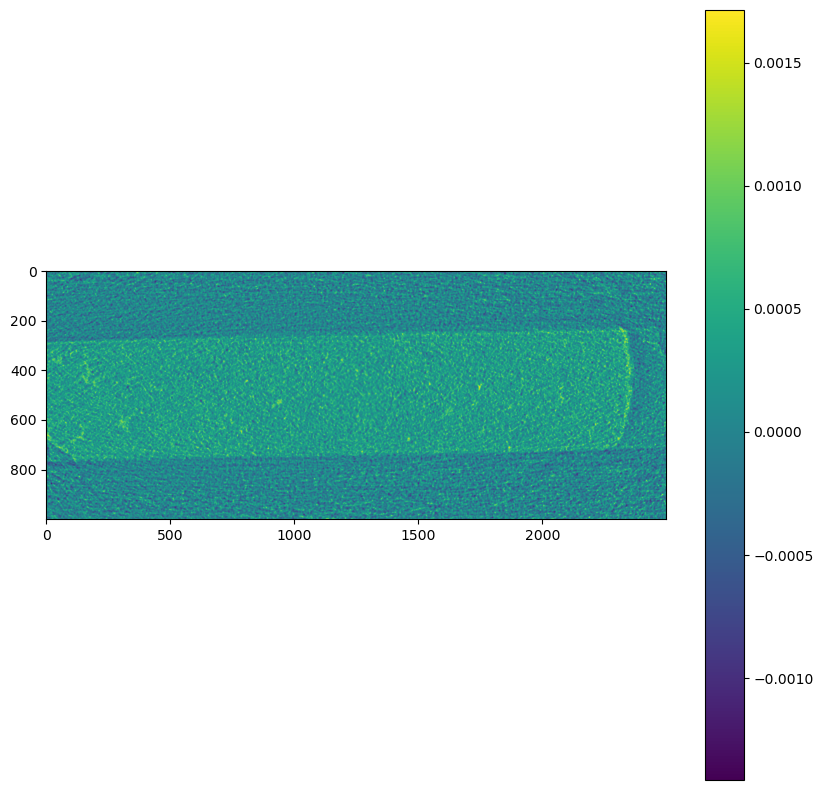

In [ ]:

image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/slice_15.tiff')
#image1 = image1[:3000:1,1300:1950:1]
plt.figure(figsize=(10,10))
plt.imshow(image1)
plt.colorbar()
plt.show()


In [ ]:

image1 = tifffile.imread('/dtu-compute/msaca/output/fbp_recon/slice_fbp_0400.tiff')
image2 = tifffile.imread('/dtu-compute/msaca/output/tv_recon/slice_tv_0400.tiff')
image3 = tifffile.imread('/dtu-compute/msaca/output/tv_recon/slice_tv_0101.tiff')
image4 = tifffile.imread('/dtu-compute/msaca/sliceA_neutron_psi/My_reconstructions/CoR_corrected_and_croppedFBP_idx_0400.tiff')
image4 = (image4.astype(np.float32)-30000)/128000

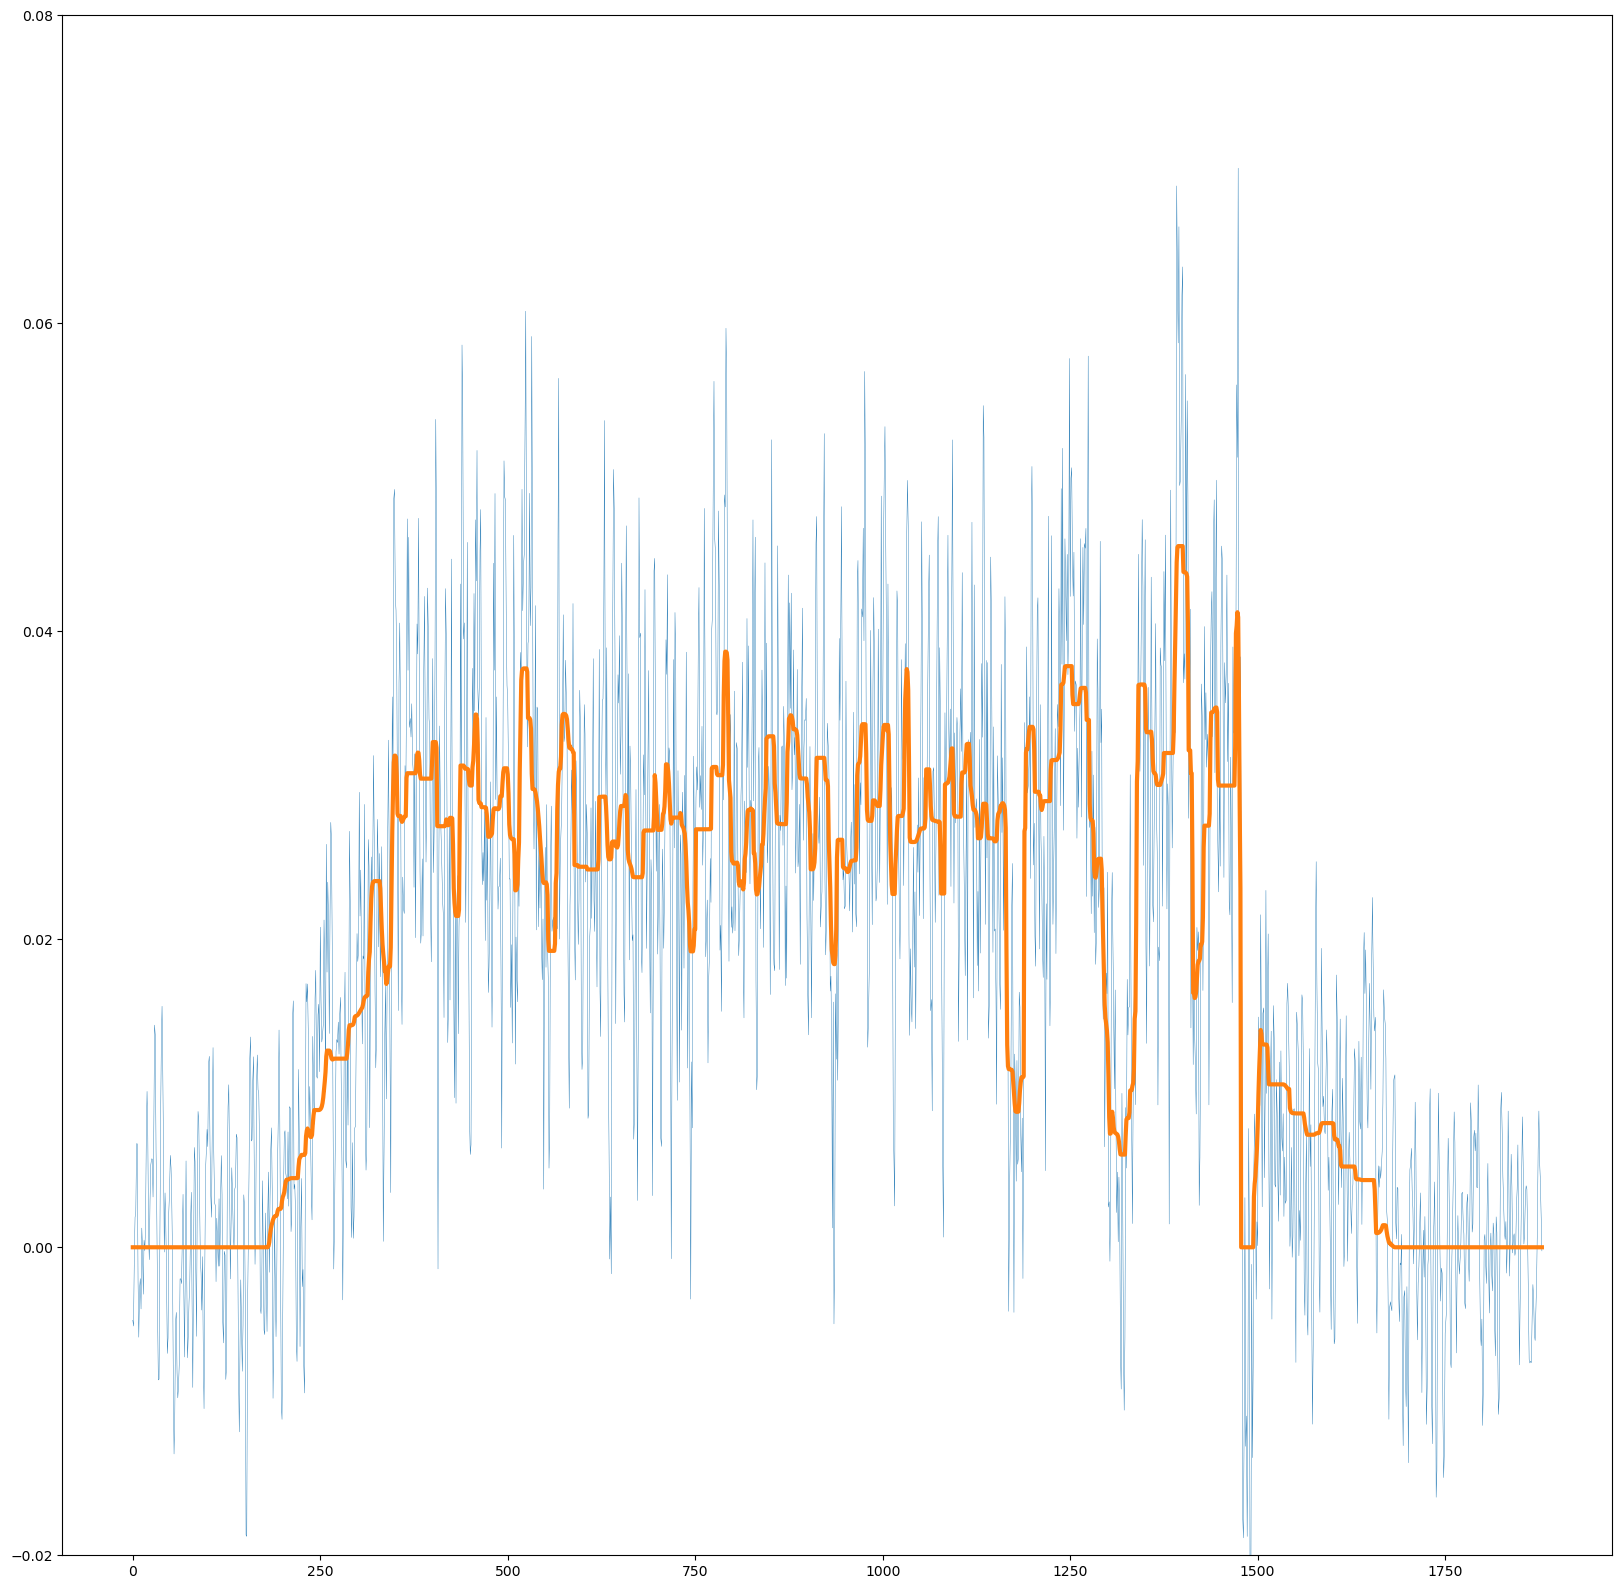

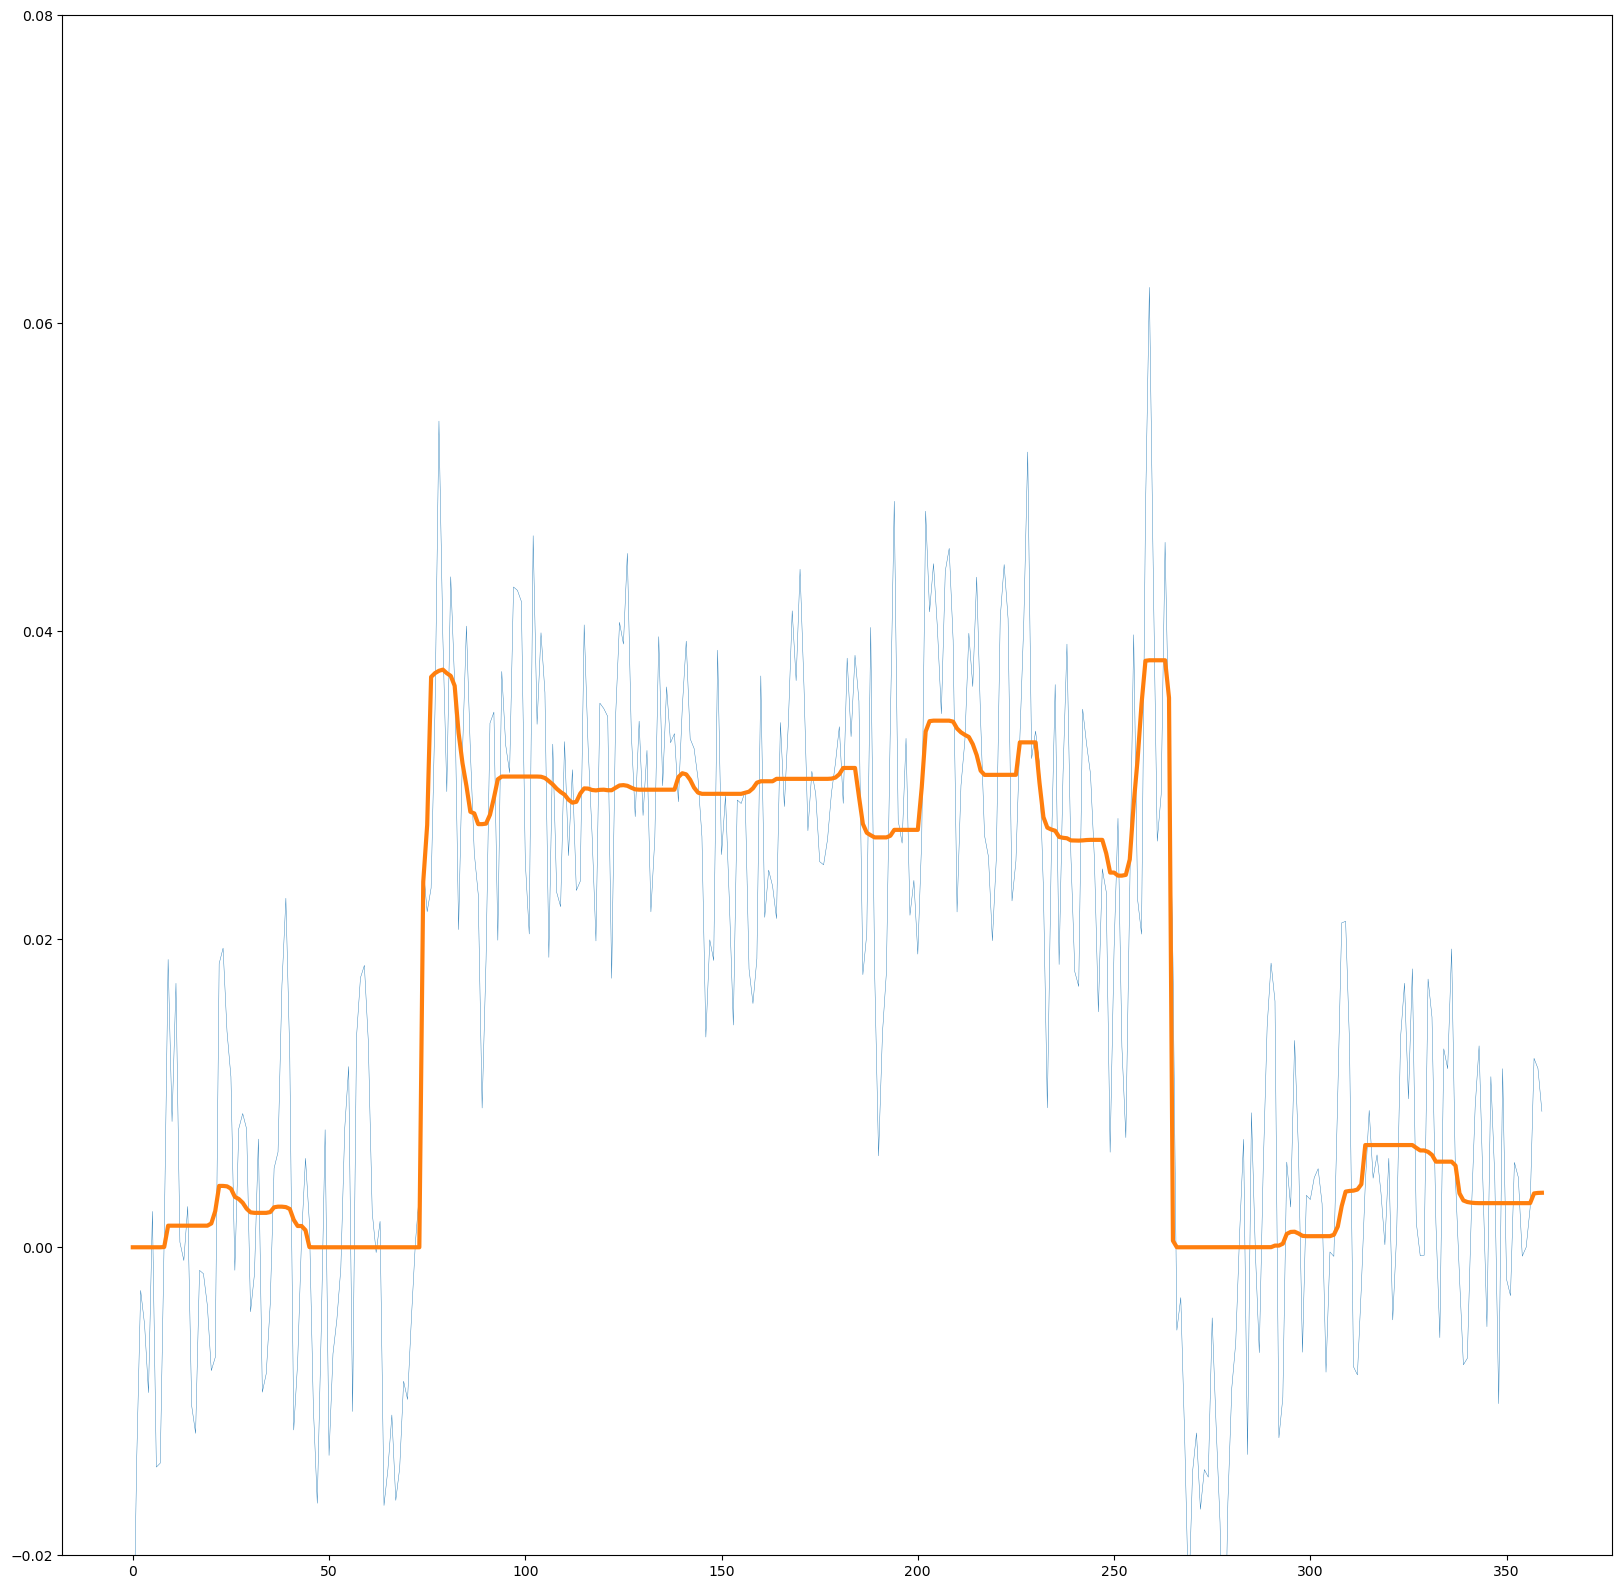

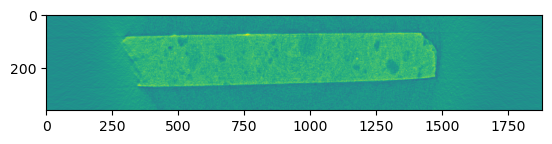

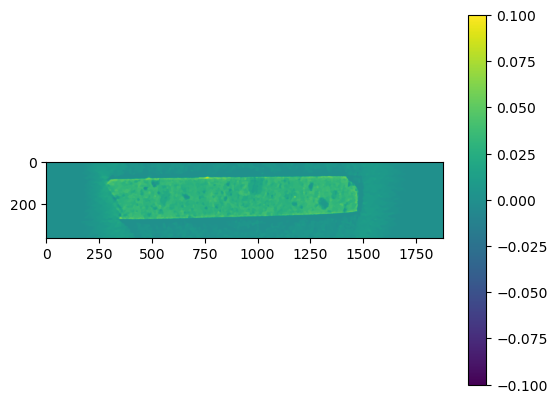

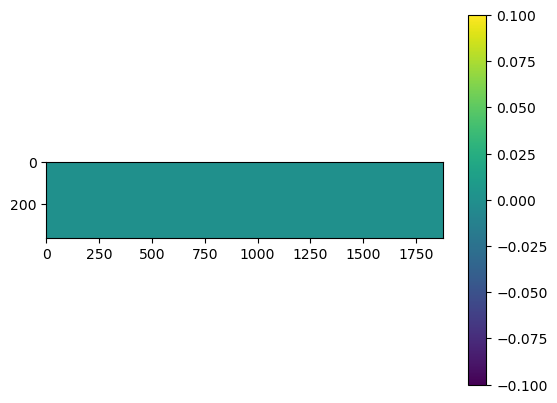

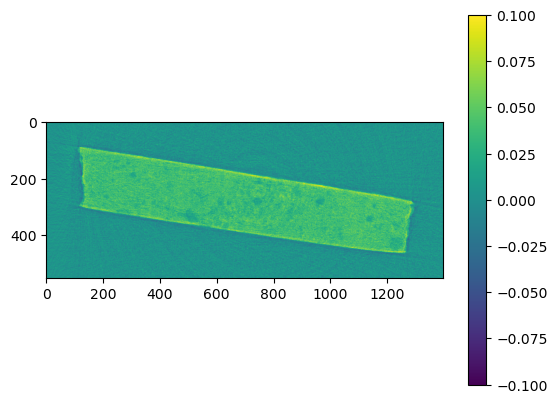

In [5]:
plt.figure(figsize=(20,20))
plt.plot(image1[200,:],lw=0.3)
plt.plot(image2[200,:],lw=3)
#plt.plot(image3[200+820,:],lw=3)
plt.ylim([-0.02,0.08])
plt.show()


plt.figure(figsize=(20,20))
plt.plot(image1[:,700],lw=0.3)
plt.plot(image2[:,700],lw=3)
plt.plot(image3[820:1180,700],lw=3)
plt.ylim([-0.02,0.08])
plt.show()

plt.imshow(image1)
plt.clim([-0.1,0.1])
plt.show()
plt.imshow(image2)
plt.clim([-0.1,0.1])
plt.colorbar()
plt.show()

plt.imshow(image3)
plt.colorbar()
plt.clim([-0.1,0.1])
plt.show()
plt.imshow(image4)
plt.colorbar()
plt.clim([-0.1,0.1])
plt.show()

In [53]:
plt.plot(image1[1000,200:1600])
plt.figure()
plt.plot(image2[1000,200:1600])
plt.figure()
plt.plot(image3[1000,200:1600])
plt.figure()
plt.plot(image4[1000,200:1600])
plt.figure()
plt.plot(image5[1000,200:1600])
plt.figure()
plt.plot(image6[1000,200:1600])
plt.figure()
plt.plot(image7[1000,200:1600])
plt.figure()
plt.plot(image8[1000,200:1600])
plt.figure()
plt.plot(image9[1000,200:1600])
plt.figure()
plt.plot(image10[1000,200:1600])
plt.figure()

IndexError: index 1000 is out of bounds for axis 0 with size 360

In [30]:
print(0)

skip = 200
N_slices = 2000
subslices = np.arange(300, N_slices-300, skip)
batch_size = 10
batches = subslices[::batch_size]
NN = len(batches)
print(subslices)
print(batches)
result = [subslices[i:i+batch_size] for i in range(0, len(subslices), batch_size)]
for i in range(NN):
    print(result[i])

0
[ 300  500  700  900 1100 1300 1500]
[300]
[ 300  500  700  900 1100 1300 1500]


In [1]:
import module_auxiliary as ma
file_pattern = '/dtu-compute/msaca/output/cache/sino_#####.tiff'
largest_number = ma.find_largest_number(file_pattern)

In [2]:
print(largest_number)

1859


In [72]:
from cil.processors import PaganinProcessor, Slicer
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer

N_pixels = 50
N_angles = 1126
N_slices = 200
angles = np.linspace(0, 360, N_angles, endpoint=True, dtype=np.float32)

ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,N_pixels//2,0])\
                            .set_angles(angles)\
                            .set_panel((N_pixels,N_slices), pixel_size=(1,1))\
                            .set_labels(labels=('vertical','angle','horizontal'))


data_batch = np.ones((50,N_angles, N_pixels))
roi = {'vertical':(0,50,1)}
processor = Slicer(roi)
processor.set_input(ag)
ag_batch = processor.get_output()
data_batch = AcquisitionData(data_batch, geometry=ag_batch)
data_batch.reorder('astra')

ag_batch.set_angles(ag_batch.angles, initial_angle=+10)
ig_batch = ag_batch.get_ImageGeometry()

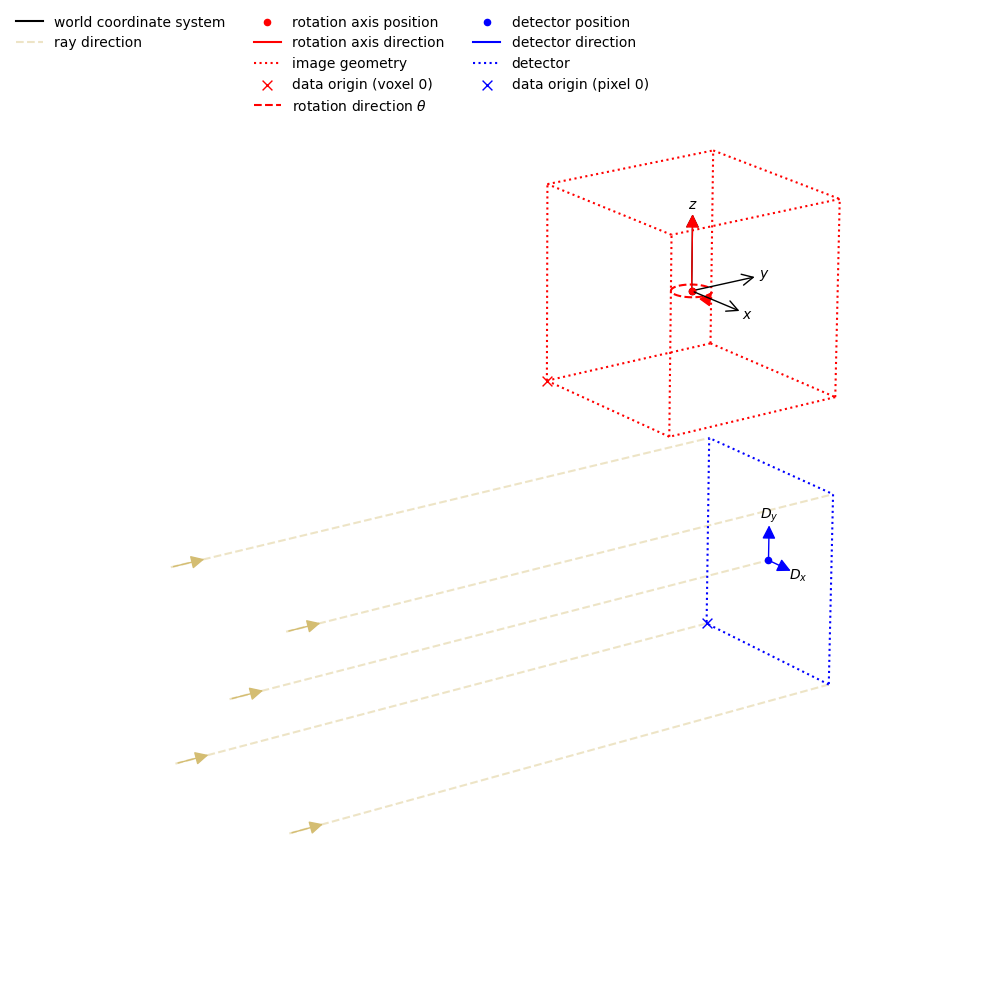

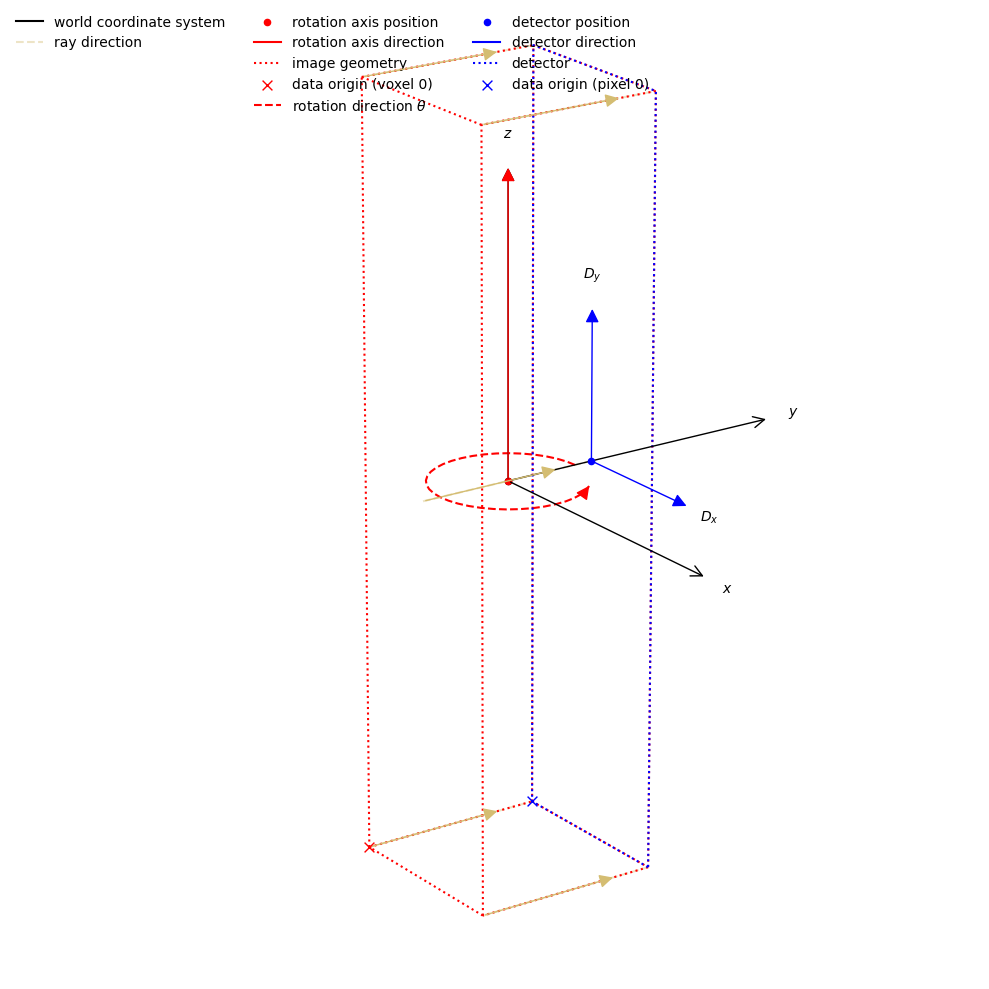

In [73]:
from cil.utilities.display import show_geometry
show_geometry(ag_batch, ig_batch)
show_geometry(ag)

In [49]:
batch

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [1]:
import module_auxiliary as ma

path_recon_tv = '/dtu-compute/msaca/output/tv_recon/slice_tv_####.tiff'
path_cache_sino = '/dtu-compute/msaca/output/cache/sino_#####.tiff'
fig_path = '/dtu-compute/msaca/output/reconstruction_.png'
N_slices = ma.find_largest_number(path_recon_tv)

/dtu-compute/msaca/output/tv_recon slice_tv_####.tiff slice slice_(\d+)\.tiff


In [3]:
print(N_slices)

None
